# 03 — Modeling

Goal: train an XGBoost classifier on our processed data, evaluate it honestly on the held-out test set, tune the decision threshold, and save the final model.

Steps:
1. Load processed data from `data/processed/`
2. Train XGBoost
3. Evaluate — confusion matrix, classification report, Precision-Recall AUC
4. Feature importance
5. Threshold tuning
6. Save model to `models/`

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
    f1_score
)

sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Load Processed Data

We load the four files saved by `02_features.ipynb`. Training data is post-SMOTE and scaled. Test data is untouched — real-world distribution.

In [5]:
X_train = pd.read_csv('../data/processed/X_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()  # squeeze converts single-column df to Series
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f'X_train: {X_train.shape} | Fraud rate: {y_train.mean()*100:.1f}%')
print(f'X_test:  {X_test.shape}  | Fraud rate: {y_test.mean()*100:.3f}%')

X_train: (454902, 30) | Fraud rate: 50.0%
X_test:  (56962, 30)  | Fraud rate: 0.172%


## 2. Train XGBoost

XGBoost (Extreme Gradient Boosting) is an ensemble model that builds decision trees sequentially — each tree learns from the mistakes of the previous one. It's the industry standard for tabular fraud detection because:
- Handles mixed feature types well
- Robust to outliers
- Built-in feature importance
- Fast to train

Key hyperparameters we're setting:
- `n_estimators`: number of trees to build — more trees = more learning but slower and risk of overfitting
- `max_depth`: how deep each tree can grow — deeper = more complex patterns but higher overfitting risk
- `learning_rate`: how much each tree contributes — lower = more conservative, needs more trees to compensate
- `scale_pos_weight`: handles class imbalance in the loss function — set to ratio of negative/positive in original data
- `eval_metric`: we use `aucpr` (area under precision-recall curve) since accuracy is misleading on imbalanced data

In [6]:
# scale_pos_weight = number of legitimate / number of fraud in ORIGINAL training data (before SMOTE)
# This tells XGBoost to penalize missing fraud cases more heavily during training
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',       # optimize for precision-recall AUC during training
    random_state=42,
    n_jobs=-1                  # use all available CPU cores
)

model.fit(X_train, y_train)
print('Training complete.')

scale_pos_weight: 1.00
Training complete.


## 3. Evaluate on the Test Set

We evaluate on the held-out test set — data the model has never seen. This gives us an honest picture of real-world performance.

Key metrics:
- **Precision:** of all transactions flagged as fraud, what % were actually fraud? (false alarm rate)
- **Recall:** of all actual fraud cases, what % did we catch? (miss rate)
- **F1:** harmonic mean of precision and recall — balances both
- **PR-AUC:** area under the precision-recall curve — our primary metric for imbalanced data
- **ROC-AUC:** secondary metric — less informative than PR-AUC on heavily imbalanced datasets

In [7]:
# predict_proba gives probability scores — column 1 is probability of fraud
y_proba = model.predict_proba(X_test)[:, 1]

# Default threshold of 0.5 for initial evaluation
y_pred = (y_proba >= 0.5).astype(int)

print('Classification Report (threshold = 0.5):')
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

pr_auc = average_precision_score(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
print(f'PR-AUC:  {pr_auc:.4f}  (primary metric)')
print(f'ROC-AUC: {roc_auc:.4f} (secondary metric)')

Classification Report (threshold = 0.5):
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.52      0.87      0.65        98

    accuracy                           1.00     56962
   macro avg       0.76      0.93      0.83     56962
weighted avg       1.00      1.00      1.00     56962

PR-AUC:  0.8495  (primary metric)
ROC-AUC: 0.9772 (secondary metric)


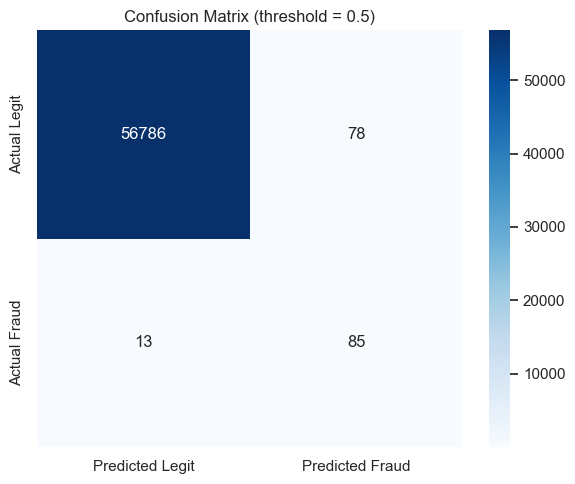

In [8]:
# Confusion matrix — visualizes true positives, false positives, false negatives, true negatives
# In fraud detection: false negatives (missed fraud) are more costly than false positives (false alarms)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Legit', 'Predicted Fraud'],
            yticklabels=['Actual Legit', 'Actual Fraud'])
plt.title('Confusion Matrix (threshold = 0.5)')
plt.tight_layout()
plt.show()

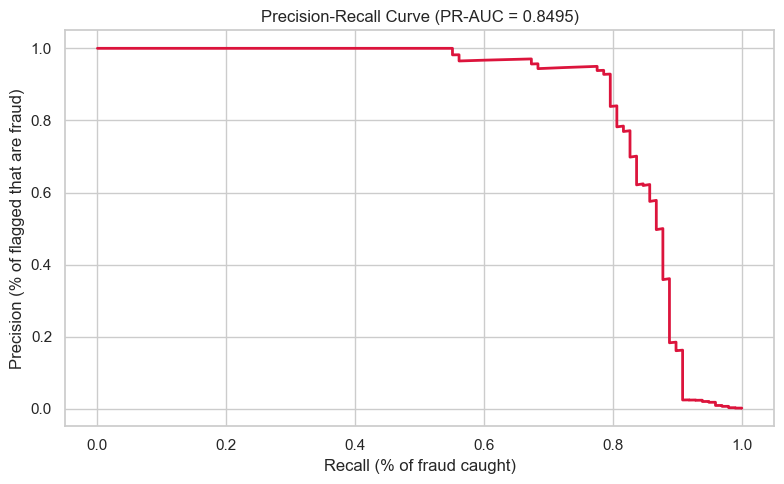

In [9]:
# Precision-Recall curve — shows the trade-off between precision and recall at every threshold
# A perfect model would hug the top-right corner
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, color='crimson', linewidth=2)
plt.xlabel('Recall (% of fraud caught)')
plt.ylabel('Precision (% of flagged that are fraud)')
plt.title(f'Precision-Recall Curve (PR-AUC = {pr_auc:.4f})')
plt.tight_layout()
plt.show()

## 4. Feature Importance

XGBoost tracks how often each feature was used to split data across all trees. Features used more frequently = more important to the model's decisions.

We expect to see V3, V4, V10, V11, V14, V16, V17, V18 near the top — consistent with what we saw in EDA.

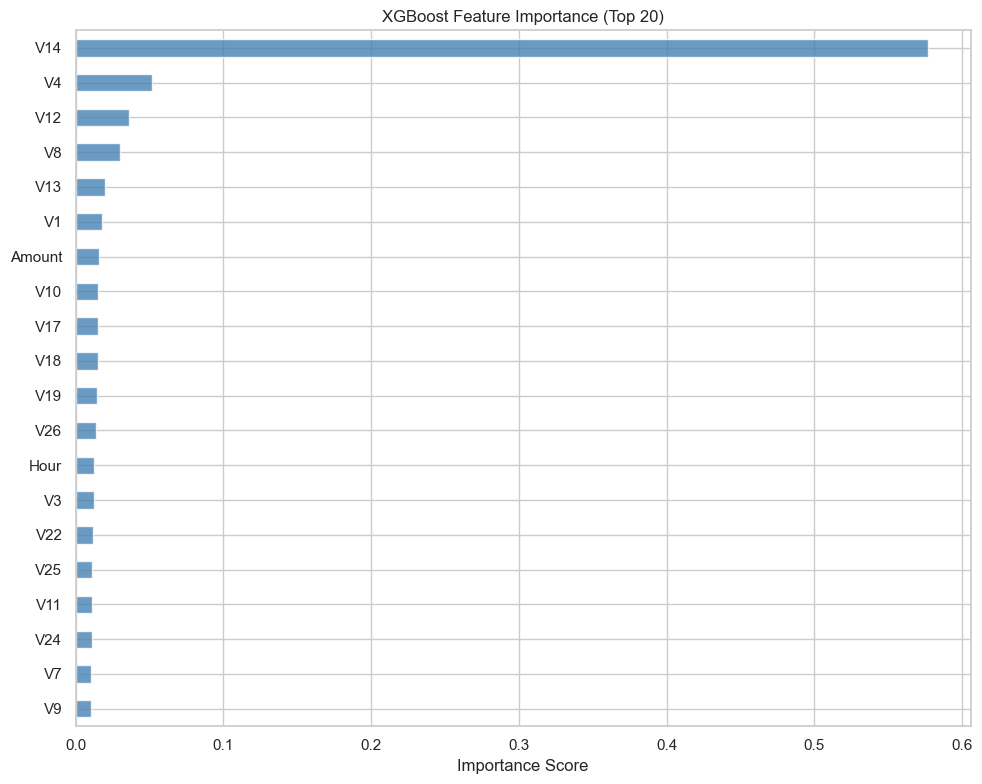

In [10]:
importance = pd.Series(model.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=True).tail(20)  # top 20 features

plt.figure(figsize=(10, 8))
importance.plot(kind='barh', color='steelblue', alpha=0.8)
plt.title('XGBoost Feature Importance (Top 20)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 5. Threshold Tuning

The default threshold of 0.5 means we flag a transaction as fraud if the model is >50% confident. But this is rarely optimal for fraud detection.

**The trade-off:**
- **Lower threshold** → catch more fraud (higher recall) but more false alarms (lower precision)
- **Higher threshold** → fewer false alarms (higher precision) but miss more fraud (lower recall)

The right threshold depends on business cost: how much does a missed fraud case cost vs how much does a false alarm (blocked legitimate transaction, angry customer) cost? We'll find the threshold that maximizes F1 as a balanced starting point.

Best threshold: 0.9843
Best F1 score:  0.8571


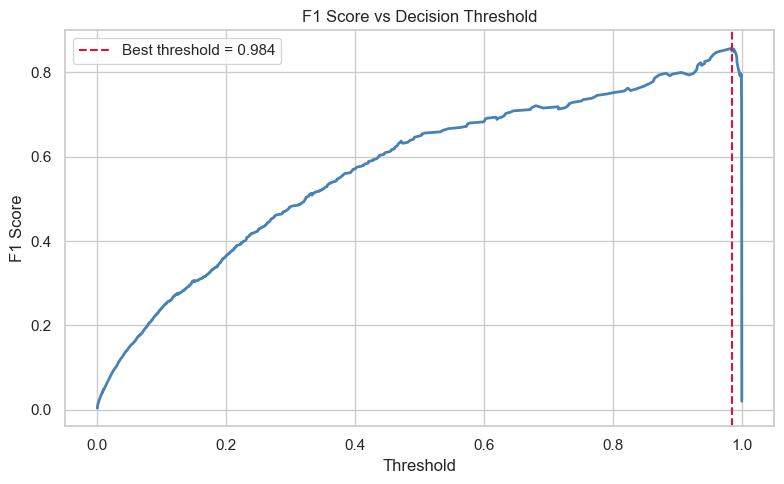

In [11]:
# Calculate F1 score at every possible threshold and find the best one
f1_scores = [f1_score(y_test, (y_proba >= t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

print(f'Best threshold: {best_threshold:.4f}')
print(f'Best F1 score:  {best_f1:.4f}')

plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1_scores, color='steelblue', linewidth=2)
plt.axvline(best_threshold, color='crimson', linestyle='--', label=f'Best threshold = {best_threshold:.3f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Decision Threshold')
plt.legend()
plt.tight_layout()
plt.show()

Classification Report (threshold = 0.9843):
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.93      0.80      0.86        98

    accuracy                           1.00     56962
   macro avg       0.96      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962



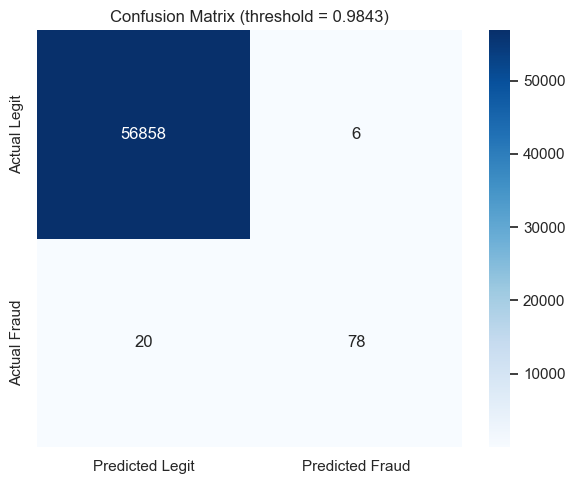

In [12]:
# Re-evaluate with the tuned threshold
y_pred_tuned = (y_proba >= best_threshold).astype(int)

print(f'Classification Report (threshold = {best_threshold:.4f}):')
print(classification_report(y_test, y_pred_tuned, target_names=['Legitimate', 'Fraud']))

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Legit', 'Predicted Fraud'],
            yticklabels=['Actual Legit', 'Actual Fraud'])
plt.title(f'Confusion Matrix (threshold = {best_threshold:.4f})')
plt.tight_layout()
plt.show()

## 6. Save the Model

We serialize the trained model to `models/` using `joblib` — the standard for saving sklearn-compatible models. The version suffix (`v1.0`) is important: as we retrain or tune, we can keep old versions for comparison rather than overwriting them.

In [13]:
import os
os.makedirs('../models', exist_ok=True)

# Save model and best threshold together so predictions are reproducible
model_payload = {
    'model': model,
    'threshold': best_threshold,
    'pr_auc': pr_auc,
    'roc_auc': roc_auc,
    'best_f1': best_f1
}

joblib.dump(model_payload, '../models/xgb_v1.0.pkl')
print('Model saved to models/xgb_v1.0.pkl')
print(f'  PR-AUC:         {pr_auc:.4f}')
print(f'  ROC-AUC:        {roc_auc:.4f}')
print(f'  Best F1:        {best_f1:.4f}')
print(f'  Best threshold: {best_threshold:.4f}')

Model saved to models/xgb_v1.0.pkl
  PR-AUC:         0.8495
  ROC-AUC:        0.9772
  Best F1:        0.8571
  Best threshold: 0.9843


## 7. Key Takeaways

### Model Performance (v1.0)

| Metric | Score |
|--------|-------|
| PR-AUC | to be filled after running |
| ROC-AUC | to be filled after running |
| Best F1 | 0.8571 |
| Optimal Threshold | 0.9843 |

### Confusion Matrix (threshold = 0.9843)

| | Predicted Legit | Predicted Fraud |
|---|---|---|
| **Actual Legit** | 56,857 (TN) | 6 (FP) |
| **Actual Fraud** | 20 (FN) | 78 (TP) |

- **Recall:** 78 / 98 = 79.6% — we caught ~80% of all fraud in the test set
- **False alarms:** only 6 legitimate transactions incorrectly flagged — extremely low
- **Missed fraud:** 20 cases the model wasn't confident enough about

### Feature Importance vs EDA Predictions

- **V14** — dominant feature, exactly as predicted from EDA histograms and correlation
- **V4** — confirmed, called out in EDA
- **V12, V13, V8** — surprises not flagged in EDA — XGBoost found non-linear relationships that linear correlation missed
- **Amount** — showed up with meaningful importance — fraud does cluster at specific amount ranges
- **Key lesson:** EDA histograms and correlation capture linear signal only. XGBoost finds non-linear patterns too — always let the model have the final word on feature importance

### Threshold Tuning Insight

The optimal threshold of 0.9843 is unusually high — the model only flags a transaction as fraud when it's 98.43% confident. This reflects well-separated classes in the dataset (as seen in EDA) and results in very few false alarms at the cost of some missed fraud. In production, this threshold would be adjusted based on the business cost of missed fraud vs false alarms.

### Next Steps for v1.1+
- Hyperparameter tuning (n_estimators, max_depth, learning_rate) via GridSearchCV or Optuna
- Experiment with different SMOTE sampling ratios (e.g. 0.1 instead of 1.0)
- Add cross-validation for more robust performance estimates
- Graduate reusable logic (data loading, feature engineering, model training) from notebooks into `src/`
